In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3080 Ti'

In [4]:
from make import load_secondary_data, load_heath_assessment_test_data

all_spectrograms, all_labels = load_secondary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [5]:
len(all_labels)

600

In [6]:
len(all_spectrograms)

600

In [7]:
from validation_util import get_label_index

valid_spec, valid_labels = load_heath_assessment_test_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 

In [8]:
len(all_spectrograms)

600

In [9]:
print(f'Initial shape of a spectrogram: ', all_spectrograms[0].shape)

ch, freq_bins = all_spectrograms[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')
print(f'Input Type: {type(all_spectrograms[0])}')


Initial shape of a spectrogram:  (33, 128)
Final shape: (33, 36)
Input Type: <class 'numpy.ndarray'>


In [10]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [19]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def get_x(i : int):
        arr = all_spectrograms[i]

        # If spectrogram is multi-channel, convert to grayscale first
        if len(arr.shape) == 3:
                arr = np.mean(arr, axis=-1)  # average across channels
        
        #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
        
        # Apply colormap to convert grayscale to color
        # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
        colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
        arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
        
        # Convert RGBA to RGB (drop alpha channel)
        arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
        
        # Convert to PyTorch tensor with correct channel ordering
        t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
        
        # Resize image
        t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
        
        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return all_labels[i]

In [12]:
from plot_util import PlotUtil

plotUtil = PlotUtil(spectrograms=all_spectrograms)

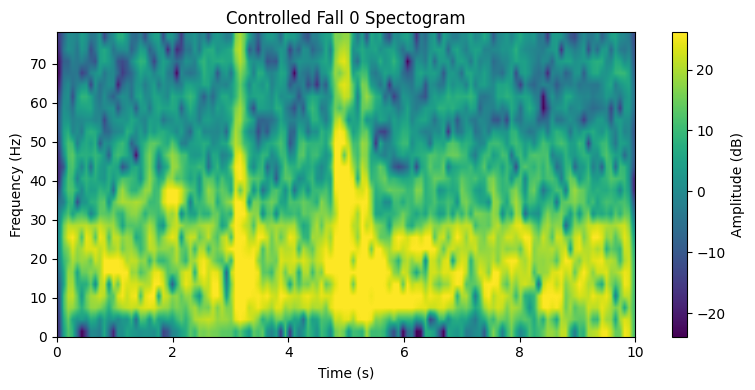

In [13]:
plotUtil.show_spec(get_label_index('Controlled Fall', all_labels), title=f'Controlled Fall {get_label_index('Controlled Fall', all_labels)} Spectogram')

<Axes: >

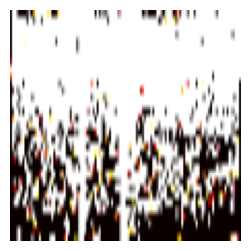

In [14]:
get_x(0).show()

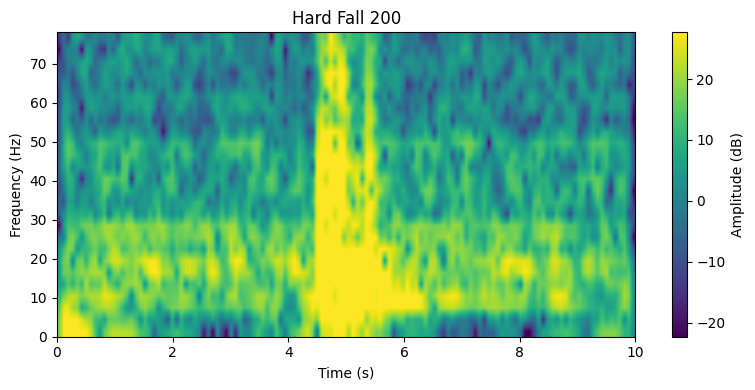

In [15]:
plotUtil.show_spec(get_label_index("Hard Fall", all_labels), title=f'Hard Fall {get_label_index("Hard Fall", all_labels)}')

<Axes: >

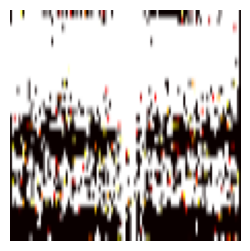

In [16]:
get_x(181).show()

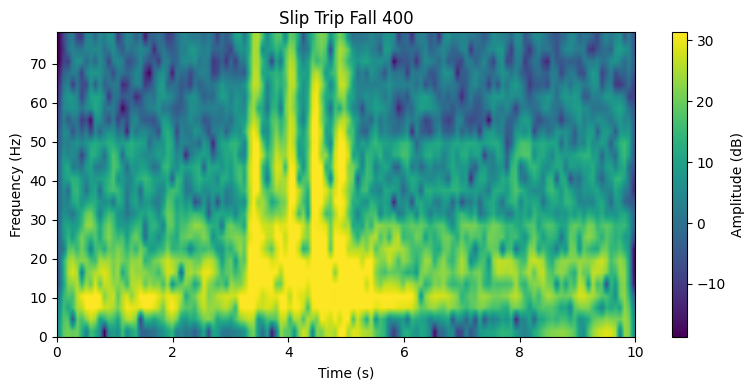

In [17]:
plotUtil.show_spec(get_label_index("SlipTrip", all_labels), title=f'Slip Trip Fall {get_label_index("SlipTrip", all_labels)}')


<Axes: >

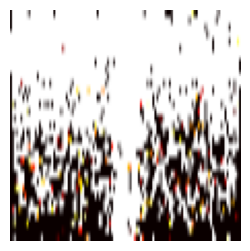

In [18]:
get_x(364).show()

In [20]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [21]:
len(all_labels)

600

In [22]:
items = list(range(len(all_spectrograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

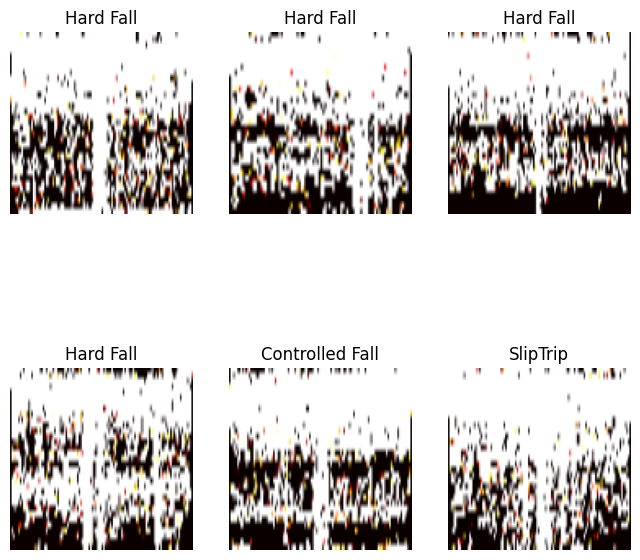

In [23]:
dls.show_batch(max_n=6, figsize=(8,8))

In [23]:
model = nn.Sequential(
    
    nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 55, 55)
    nn.BatchNorm2d(8),
    nn.ReLU(),
            
    nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 27, 27)
    nn.BatchNorm2d(16),
    nn.ReLU(),
        
    nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 13, 13)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64*6*6, 14)
)

## Only run if you dont have a learner yet! 

In [24]:
learner = vision_learner(dls, resnet34, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

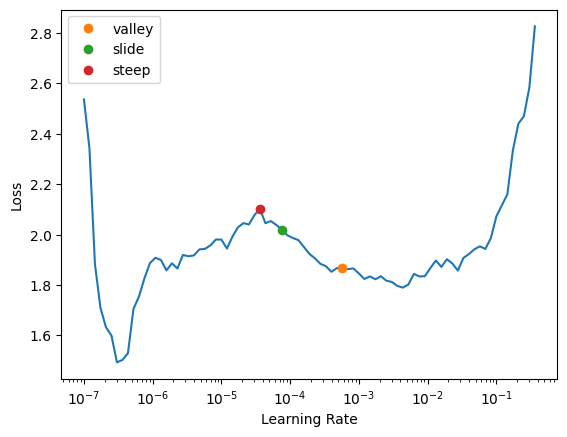

In [25]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))

In [26]:
learner.fine_tune(20)

epoch,train_loss,valid_loss,accuracy,time
0,1.800220,1.349149,0.550000,00:01


epoch,train_loss,valid_loss,accuracy,time
0,1.228986,1.275695,0.525000,00:01
1,0.850029,1.107215,0.566667,00:01
2,0.572051,1.231477,0.541667,00:01
3,0.422229,1.401188,0.566667,00:01
4,0.502004,1.370601,0.625000,00:01
5,0.472615,1.522146,0.658333,00:01
6,0.437243,1.460105,0.683333,00:01
7,0.359050,0.971196,0.708333,00:01
8,0.304035,1.016716,0.700000,00:01
9,0.303051,1.143701,0.716667,00:01


In [27]:
learner.unfreeze()

In [28]:
learner.fit_one_cycle(30, lr.valley)

epoch,train_loss,valid_loss,accuracy,time
0,0.071782,0.944987,0.766667,00:01
1,0.113650,0.861486,0.733333,00:01
2,0.294416,1.541079,0.691667,00:01
3,0.575209,0.813163,0.741667,00:01
4,0.542202,1.497929,0.658333,00:01
5,0.488787,0.694983,0.716667,00:01
6,0.420869,0.477037,0.800000,00:01
7,0.363000,0.793540,0.750000,00:01
8,0.338342,0.763815,0.800000,00:01
9,0.291293,0.632340,0.800000,00:01


In [30]:
learner.summary()

Sequential (Input shape: 12 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     12 x 64 x 56 x 56   
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     12 x 64 x 28 x 28   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      

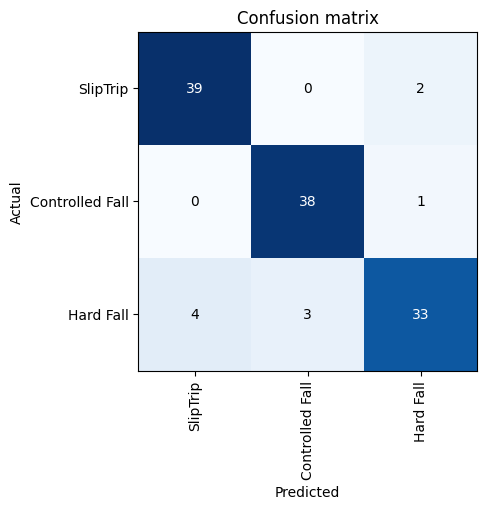

In [31]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [32]:
inter_plot.most_confused()

[('Hard Fall', 'SlipTrip', np.int64(4)),
 ('Hard Fall', 'Controlled Fall', np.int64(3)),
 ('SlipTrip', 'Hard Fall', np.int64(2)),
 ('Controlled Fall', 'Hard Fall', np.int64(1))]

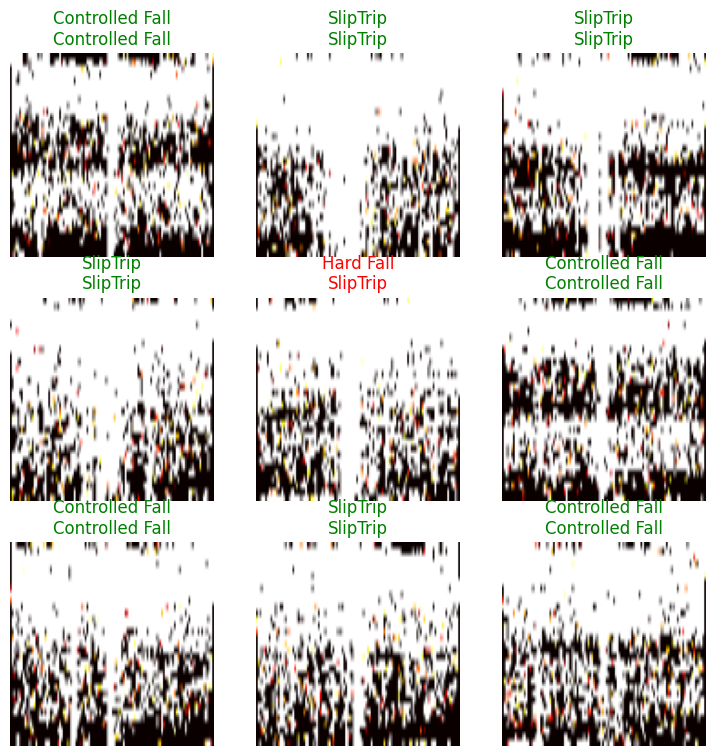

In [33]:
learner.show_results()

In [11]:
learner = False

In [12]:
if not learner:
    learner = load_learner("./models/ha-model.pkl")

/media/Delta/code/Master/Master-project/vibration_model/.venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [13]:
def get_x_test(i):
    arr = valid_spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
        arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [14]:
learner.validate()

/media/Delta/code/Master/Master-project/vibration_model/.venv/lib/python3.12/site-packages/fastprogress/fastprogress.py:73: UserWarning: Your generator is empty.
  warn("Your generator is empty.")


(#2) [None,None]

## Accuracy

This is the relationship between True labes, and all predicted labels. This determens how accurate the model is to predict the true lables. 

$$Accuracy = \frac{TP + TN}{TP + TN + FN + FP} $$

## Precision

The amount of True (or False) labels the model did find belonging to the positive class. The number of True Positives divided by True Positives plus False Positives.  

$$ Precision = \frac{TP}{TP + FP} $$

In [15]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test 
    


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [17]:
y_pred, y_test = get_y_pred(learner, valid_spec)

In [ ]:
dls.vocab = ["Controlled Fall", "Hard Fall", "SlipTrip"]

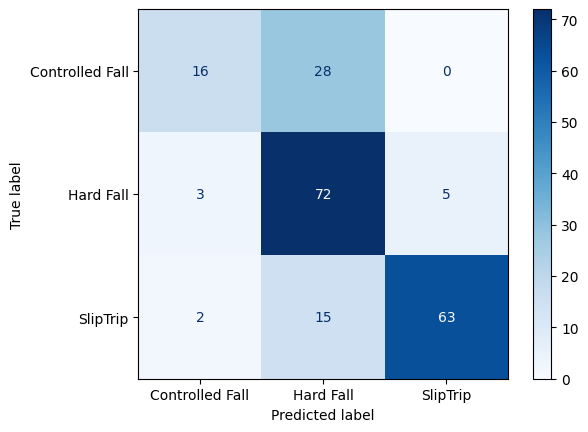

In [24]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [25]:
accuracy_score(y_test, y_pred)

0.7401960784313726

In [26]:
precision_score(y_test, y_pred, average='weighted')

0.7731784956096676

In [27]:
recall_score(y_test, y_pred, average="weighted")

0.7401960784313726

In [28]:
f1_score(y_test, y_pred, average="weighted")

0.7296400472871061

In [45]:
dir = Path('./models')

learner.path = dir

learner.export('ha-model.pkl')